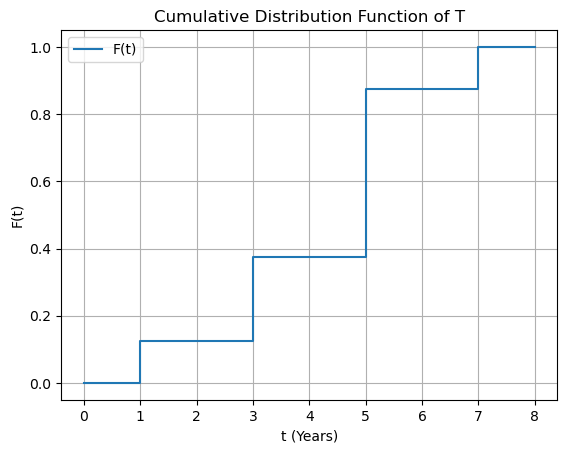

   T  P(T=t)
0  1   0.125
1  3   0.250
2  5   0.500
3  7   0.125
P(1.4 < T < 6) = 0.75
P(T ≤ 5 | T ≥ 2) = 0.42857142857142855


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Problem 1 (a)
def plot_cdf():
    t_values = [0, 1, 3, 5, 7, 8]
    F_values = [0, 1/8, 3/8, 7/8, 1, 1]
    
    plt.step(t_values, F_values, where='post', label='F(t)')
    plt.xlabel('t (Years)')
    plt.ylabel('F(t)')
    plt.title('Cumulative Distribution Function of T')
    plt.grid()
    plt.legend()
    plt.show()

plot_cdf()

# Problem 1 (b)
probability_table = pd.DataFrame({
    'T': [1, 3, 5, 7],
    'P(T=t)': [1/8, 2/8, 4/8, 1/8]
})
print(probability_table)

# Problem 1 (c) 
P_1_4_T_6 = (3/8 - 1/8) + (7/8 - 3/8)
print("P(1.4 < T < 6) =", P_1_4_T_6)

# Problem 1 (d) - Conditional Probability P(T ≤ 5 | T ≥ 2)
P_T_le_5_given_T_ge_2 = (3/8) / (7/8)
print("P(T ≤ 5 | T ≥ 2) =", P_T_le_5_given_T_ge_2)




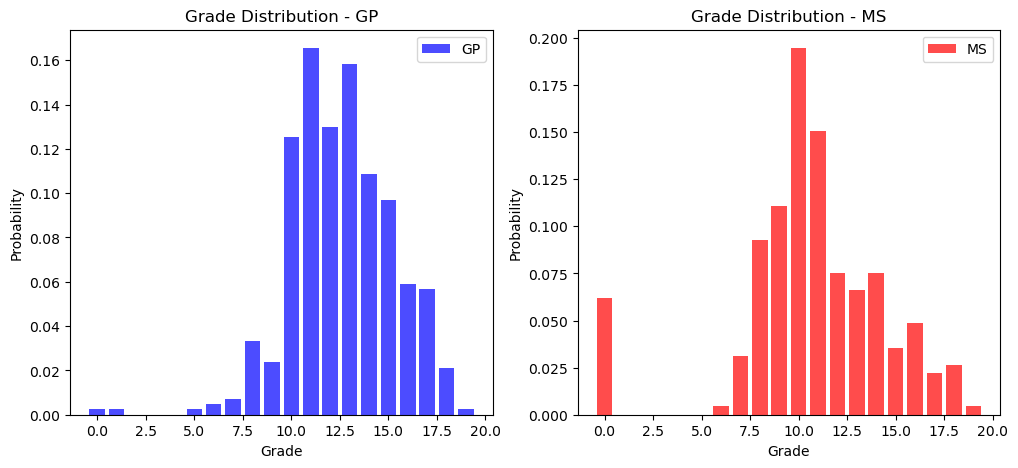

GP Mean: 12.576832151300236, GP Standard Deviation: 2.62253056426027
MS Mean: 10.650442477876107, MS Standard Deviation: 3.825499536906024
GP students performed better on average.
MS has higher variability in grades.


In [9]:
# Problem 2 
df = pd.read_csv(r"C:/Users/dunca/OneDrive/Desktop/STAT 603/HW7/student-por.csv")

# Separate the two schools
gp_grades = df[df['school'] == 'GP']['G3']
ms_grades = df[df['school'] == 'MS']['G3']

# Compute probability distributions
def compute_prob_dist(grades):
    values, counts = np.unique(grades, return_counts=True)
    probabilities = counts / len(grades)
    return pd.DataFrame({'Grade': values, 'Probability': probabilities})

gp_prob_dist = compute_prob_dist(gp_grades)
ms_prob_dist = compute_prob_dist(ms_grades)

# Plot probability distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(gp_prob_dist['Grade'], gp_prob_dist['Probability'], color='blue', alpha=0.7, label='GP')
axes[1].bar(ms_prob_dist['Grade'], ms_prob_dist['Probability'], color='red', alpha=0.7, label='MS')
axes[0].set_title('Grade Distribution - GP')
axes[1].set_title('Grade Distribution - MS')
for ax in axes:
    ax.set_xlabel('Grade')
    ax.set_ylabel('Probability')
    ax.legend()
plt.show()

# Compute Mean and Standard Deviation
gp_mean = np.mean(gp_grades)
gp_std = np.std(gp_grades)
ms_mean = np.mean(ms_grades)
ms_std = np.std(ms_grades)

print(f"GP Mean: {gp_mean}, GP Standard Deviation: {gp_std}")
print(f"MS Mean: {ms_mean}, MS Standard Deviation: {ms_std}")

# Conclusion
if gp_mean > ms_mean:
    print("GP students performed better on average.")
elif gp_mean < ms_mean:
    print("MS students performed better on average.")
else:
    print("Both schools performed equally on average.")

if gp_std > ms_std:
    print("GP has higher variability in grades.")
elif gp_std < ms_std:
    print("MS has higher variability in grades.")
else:
    print("Both schools have similar variability.")